# Homework: Photometric reverberation mapping

<span style="color:red">**Deadline:** </span> 15 May 2026.

# Task 1

**Goal:**

- Understand the photometric reverberation mapping method and its limitations. 
- Introduction to the tools for simulating AGN light curves and performing photoRM.

<span style="color:blue">**a)**</span> Familiarize yourself with photRM module (read the docs located in photRM.py). Using the `lc_two_bands` function from the `photRM` module, construct **three pairs** of continuum and emission line light curves of length 5000 days. This is a hypothetical scenario where we generate pairs of light curves as if they are observed in two broadband filters:

   - one covering only continuum emission (we will name it *x-band*)
   - second covering emission line and the underlying continuum (we will name it *y-band*)

Make sure that the light curve pairs are simulated for the artificial AGN objects at z = 0.1 having luminosity (log L): 43, 44, and 45, respectively. The emission line contribution to the total integrated flux should be 25% and the continuum contribution 75% in all cases. Plot the first 1000 days of the light curves and compare the properties (printed when you run `lc_two_bands`) of these three simulated AGN objects. How would you explain the correlation between AGN luminosity and broad line region dimensions (i.e. time-lag)? Cut the light curve length to 1000 points and save them for later use.

<span style="color:blue">**b)**</span> Using the photometric reverberation mapping method and the `pyzdcf` module, estimate the time-lag (broad line region radius) for these three light curve pairs. You can use the default values for keyword arguments in the function. How do the time-lag estimates compare to the values reported by `lc_two_bands`? You can estimate the time-lag using the `photRM.peak_finder` or (optionally) you can compile a Fortran code [PLIKE](https://www.weizmann.ac.il/particle/tal/research-activities/software) to obtain more accurate results and errors. Similarly display the results as in Astro Data Lab notebook.

>To install pyzdcf:
>
>   `pip install pyzdcf`
>    
>or you can run this notebook in Astro Data Lab where `pyzdcf` is already installed.

> To run PLIKE:
>
> - download the source code [here](https://webhome.weizmann.ac.il/home/tal/zdcf/plike_v4.0.f90)
> - if you don't have a fortran compiler, I suggest you install `gfortran` on your system
> - navigate to the folder containing the downloaded file
> - from there, run the following commands in the terminal:  
> `gfortran -o plike source_code_filename`  
> `./plike`

<span style="color:blue">**c) (optionally)**</span> Now, to reflect a real-world scenario, let's make one of these three pairs of simulated light curves gappier (e.g., the one with log(L) = 44). Alter the light curves so they have the following cadences:

- one observation every 5 days
- one months of observations every day, then one month pause. Repeat the pattern.
- three month of observations every day, followed by six months of observations with a frequency of once per month and then a gap of three months. Repeat the pattern.

Estimate the time-lag from these three pairs of light curves. Write your conclusions regarding the accuracy of time-lag retrieval for different observing strategies you implemented. The light curves should not be longer than 1000 days.

## Task 1(a): Simulated AGN Light Curves

Properties of the simulated AGN object:
---------------------------------------
log(L) = 43.00
MBH = 3.14e+06 M_sun
tau_DRW = 17.31 days
sigma_DRW = 0.05 mag^2/day
Time-lag = 9.86 days


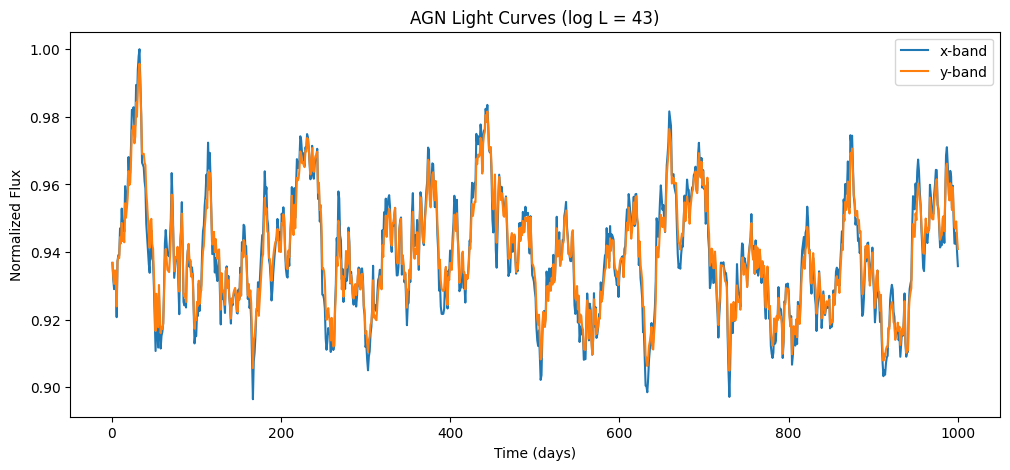

In [26]:
import photRM
import numpy as np
import matplotlib.pyplot as plt

# =========================
# AGN with log(L) = 43
# =========================

x1, y1, line1 = photRM.lc_two_bands(
    T=5000,          # total light curve length
    osc=False,
    A=0.14,
    noise=0.00005,
    z=0.1,
    lum=43
)

# Plot only first 1000 days
plt.figure(figsize=(12,5))

plt.plot(
    x1.iloc[:1000,0],
    x1.iloc[:1000,1],
    label='x-band'
)

plt.plot(
    y1.iloc[:1000,0],
    y1.iloc[:1000,1],
    label='y-band'
)

plt.xlabel("Time (days)")
plt.ylabel("Normalized Flux")
plt.title("AGN Light Curves (log L = 43)")
plt.legend()

plt.show()

Properties of the simulated AGN object:
---------------------------------------
log(L) = 44.00
MBH = 1.46e+07 M_sun
tau_DRW = 31.98 days
sigma_DRW = 0.03 mag^2/day
Time-lag = 33.65 days


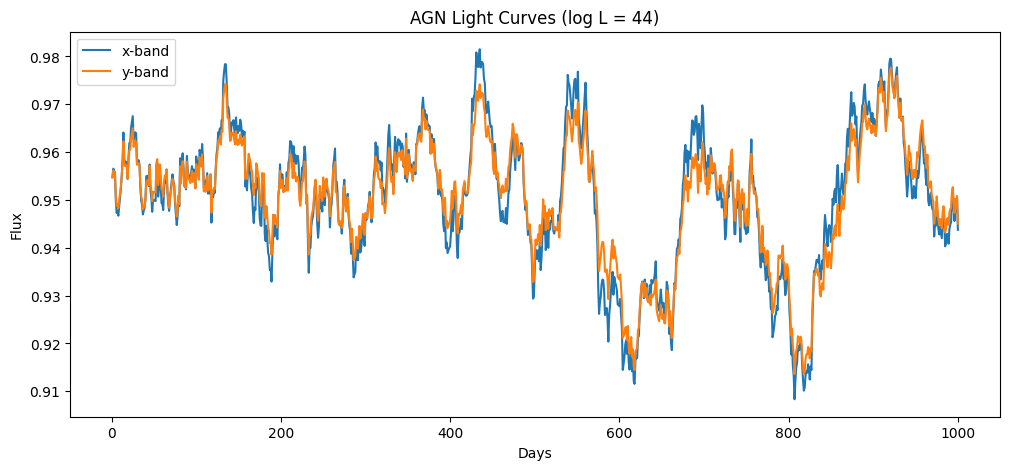

In [27]:
x2, y2, line2 = photRM.lc_two_bands(
    T=5000,
    osc=False,
    A=0.14,
    noise=0.00005,
    z=0.1,
    lum=44
)
plt.figure(figsize=(12,5))

plt.plot(
    x2.iloc[:1000,0],
    x2.iloc[:1000,1],
    label='x-band'
)

plt.plot(
    y2.iloc[:1000,0],
    y2.iloc[:1000,1],
    label='y-band'
)

plt.xlabel("Days")
plt.ylabel("Flux")
plt.title("AGN Light Curves (log L = 44)")
plt.legend()

plt.show()

Properties of the simulated AGN object:
---------------------------------------
log(L) = 45.00
MBH = 6.76e+07 M_sun
tau_DRW = 59.10 days
sigma_DRW = 0.01 mag^2/day
Time-lag = 114.82 days


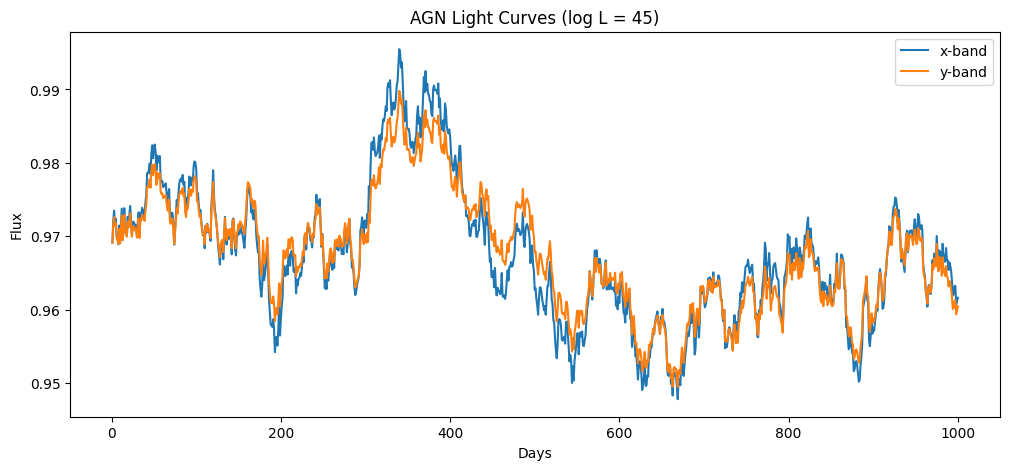

In [28]:

x3, y3, line3 = photRM.lc_two_bands(
    T=5000,
    osc=False,
    A=0.14,
    noise=0.00005,
    z=0.1,
    lum=45
)
plt.figure(figsize=(12,5))

plt.plot(
    x3.iloc[:1000,0],
    x3.iloc[:1000,1],
    label='x-band'
)

plt.plot(
    y3.iloc[:1000,0],
    y3.iloc[:1000,1],
    label='y-band'
)

plt.xlabel("Days")
plt.ylabel("Flux")
plt.title("AGN Light Curves (log L = 45)")
plt.legend()

plt.show()

In [29]:
np.savetxt("AGN43_xband.txt", x1[:1000])
np.savetxt("AGN43_yband.txt", y1[:1000])

np.savetxt("AGN44_xband.txt", x2[:1000])
np.savetxt("AGN44_yband.txt", y2[:1000])

np.savetxt("AGN45_xband.txt", x3[:1000])
np.savetxt("AGN45_yband.txt", y3[:1000])


## Discussion
In this task, three pairs of AGN light curves were simulated using the `lc_two_bands()` function from the `photRM` module.

The simulations were performed for AGN luminosities:

- log(L) = 43
- log(L) = 44
- log(L) = 45

Each light curve has a total duration of 5000 days.  
The x-band contains only continuum emission, while the y-band contains both continuum and emission-line contributions.

The emission-line contribution was set to 25% and the continuum contribution to 75%.

Only the first 1000 days are plotted and saved for later analysis.

## Task 1(b): Time-lag Estimation 



In [5]:
!pip install pyzdcf

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as plticker

import photRM
from pyzdcf import pyzdcf
np.random.seed(0)

In [43]:
input_dir = './'
output_dir = './'

params = dict(
    autocf=True,
    prefix='acf43',
    uniform_sampling=False,
    omit_zero_lags=True,
    minpts=0,
    num_MC=100,
    lc1_name='AGN43_xband.txt'
)

acf_43 = pyzdcf(
    input_dir,
    output_dir,
    intr=False,
    parameters=params,
    sep=' ',
    sparse='auto'
)


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

990 bins actually used, 45.0 inter-dependent pairs discarded.


acf43.dcf written...

pyZDCF ended.



In [44]:
params = dict(
    autocf=False,
    prefix='ccf43',
    uniform_sampling=False,
    omit_zero_lags=True,
    minpts=0,
    num_MC=100,
    lc1_name='AGN43_xband.txt',
    lc2_name='AGN43_yband.txt'
)

ccf_43 = pyzdcf(
    input_dir,
    output_dir,
    intr=False,
    parameters=params,
    sep=' ',
    sparse='auto'
)


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   False
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

992 bins actually used, 500032 inter-dependent pairs discarded.


ccf43.dcf written...

pyZDCF ended.



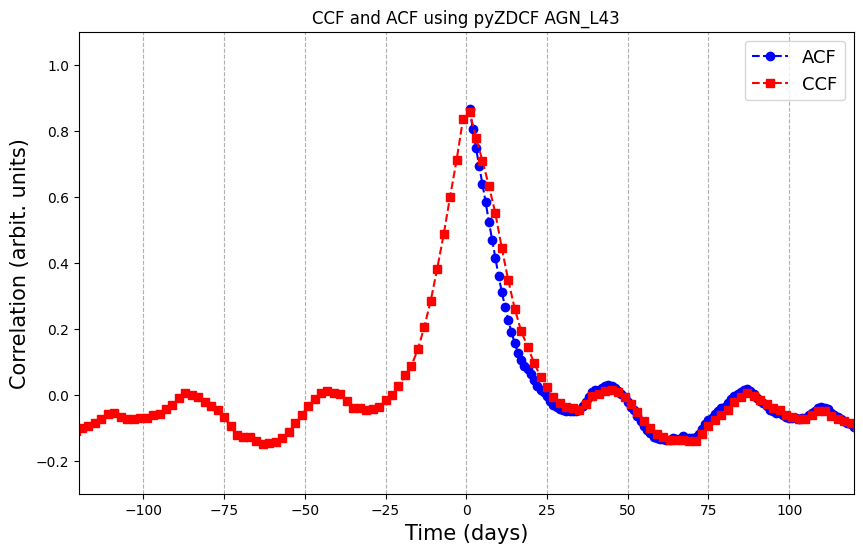

In [45]:
fig = plt.figure(figsize=(10,6))

ax = fig.add_subplot(111)

ax.plot(
    acf_43['tau'],
    acf_43['dcf'],
    'o--b',
    label='ACF'
)

ax.plot(
    ccf_43['tau'],
    ccf_43['dcf'],
    's--r',
    label='CCF'
)

ax.set_xlim(-120,120)
ax.set_ylim(-0.3,1.1)

ax.set_xlabel("Time (days)", fontsize=15)
ax.set_ylabel("Correlation (arbit. units)", fontsize=15)

ax.legend(fontsize=13)

loc = plticker.MultipleLocator(25)
ax.xaxis.set_major_locator(loc)

ax.grid(which='major', axis='x', linestyle='--')

plt.title("CCF and ACF using pyZDCF AGN_L43")

plt.show()

In [46]:
acf_43 = photRM.add_inverted_acf(acf_43)

In [47]:
acf_43 = photRM.interp(ccf_43, acf_43)

In [48]:
final_ccf_43 = photRM.delta_ccf(acf_43, ccf_43)

In [49]:
tau43, peaks_x, peaks_y = photRM.peak_finder(
    final_ccf_43.dcf.values,
    final_ccf_43.tau.values,
    (-50,150)
)

print("Peak candidates:", peaks_x)
print("Maximum peak =", tau43)

Peak candidates (x-axis vals):  [  9.  55.  95. 119. 141.]
Max. peak:  9.0
Peak candidates: [  9.  55.  95. 119. 141.]
Maximum peak = 9.0


In [50]:
err_low = final_ccf_43.loc[
    final_ccf_43.tau == tau43,
    '-sig(tau)'
].values[0]

err_high = final_ccf_43.loc[
    final_ccf_43.tau == tau43,
    '+sig(tau)'
].values[0]

print(err_low, err_high)

0 0


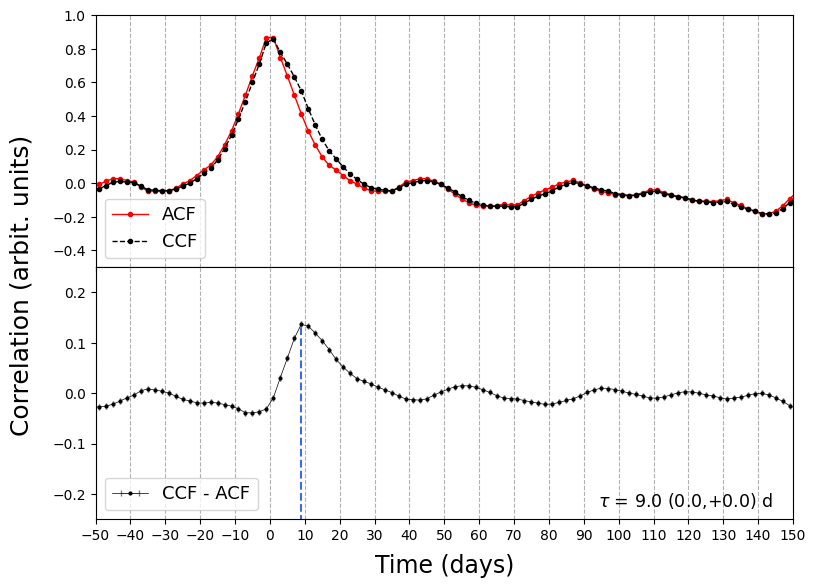

In [51]:
lims_x = (-50,150)
lims_y = (-0.5,1)

err = (err_low*(-1), err_high)

photRM.plot_ccf_acf(
    final_ccf_43,
    ccf_43,
    acf_43,
    locator=10,
    peak=True,
    tau=tau43,
    err=err,
    lims_x=lims_x,
    lims_y=lims_y
)

In [52]:
params = dict(
    autocf=True,
    prefix='acf44',
    uniform_sampling=False,
    omit_zero_lags=True,
    minpts=0,
    num_MC=100,
    lc1_name='AGN44_xband.txt'
)

acf_44 = pyzdcf(
    input_dir,
    output_dir,
    intr=False,
    parameters=params,
    sep=' ',
    sparse='auto'
)


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

990 bins actually used, 45.0 inter-dependent pairs discarded.


acf44.dcf written...

pyZDCF ended.



In [53]:
params = dict(
    autocf=False,
    prefix='ccf44',
    uniform_sampling=False,
    omit_zero_lags=True,
    minpts=0,
    num_MC=100,
    lc1_name='AGN44_xband.txt',
    lc2_name='AGN44_yband.txt'
)

ccf_44 = pyzdcf(
    input_dir,
    output_dir,
    intr=False,
    parameters=params,
    sep=' ',
    sparse='auto'
)


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   False
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

992 bins actually used, 500032 inter-dependent pairs discarded.


ccf44.dcf written...

pyZDCF ended.



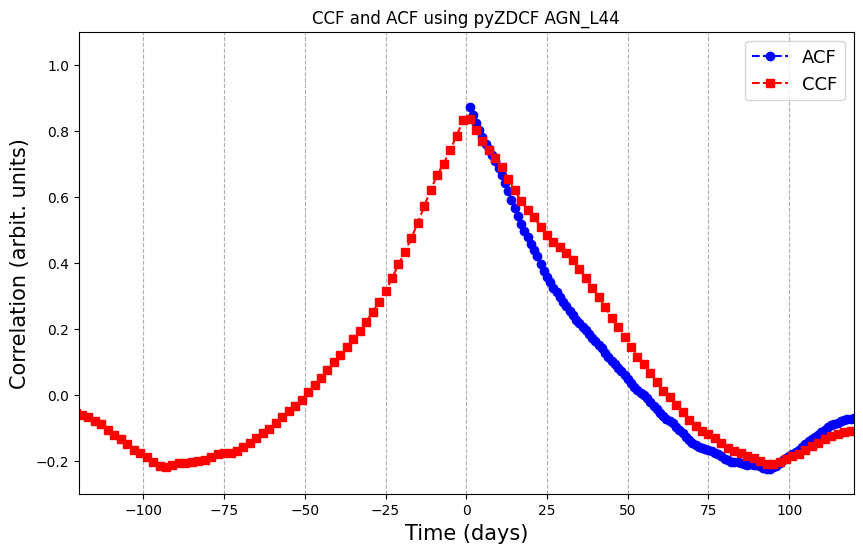

In [54]:
fig = plt.figure(figsize=(10,6))

ax = fig.add_subplot(111)

ax.plot(
    acf_44['tau'],
    acf_44['dcf'],
    'o--b',
    label='ACF'
)

ax.plot(
    ccf_44['tau'],
    ccf_44['dcf'],
    's--r',
    label='CCF'
)

ax.set_xlim(-120,120)
ax.set_ylim(-0.3,1.1)

ax.set_xlabel("Time (days)", fontsize=15)
ax.set_ylabel("Correlation (arbit. units)", fontsize=15)

ax.legend(fontsize=13)

loc = plticker.MultipleLocator(25)
ax.xaxis.set_major_locator(loc)

ax.grid(which='major', axis='x', linestyle='--')

plt.title("CCF and ACF using pyZDCF AGN_L44")

plt.show()

In [55]:
acf_44 = photRM.add_inverted_acf(acf_44)

acf_44 = acf_44.drop_duplicates(subset='tau').sort_values('tau')
ccf_44 = ccf_44.drop_duplicates(subset='tau').sort_values('tau')

acf_44 = photRM.interp(ccf_44, acf_44)

In [56]:
final_ccf_44 = photRM.delta_ccf(acf_44, ccf_44)

In [57]:
tau44, peaks_x, peaks_y = photRM.peak_finder(
    final_ccf_44.dcf.values,
    final_ccf_44.tau.values,
    (-50,150)
)

print("Peak candidates:", peaks_x)
print("Maximum peak =", tau44)

Peak candidates (x-axis vals):  [ 33. 147.]
Max. peak:  33.0
Peak candidates: [ 33. 147.]
Maximum peak = 33.0


In [58]:
err_low = final_ccf_44.loc[
    final_ccf_44.tau == tau44,
    '-sig(tau)'
].values[0]

err_high = final_ccf_44.loc[
    final_ccf_44.tau == tau44,
    '+sig(tau)'
].values[0]

print(err_low, err_high)

0 0


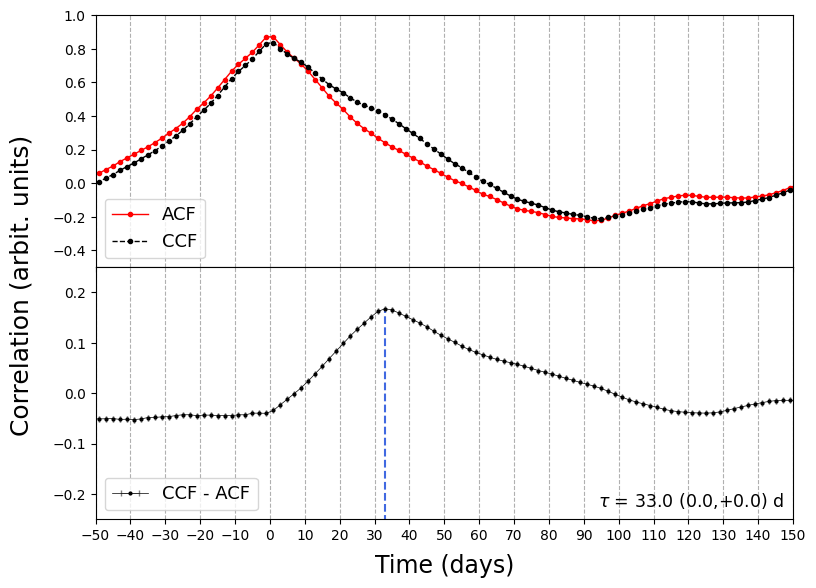

In [59]:
lims_x = (-50,150)
lims_y = (-0.5,1)

err = (err_low*(-1), err_high)

photRM.plot_ccf_acf(
    final_ccf_44,
    ccf_44,
    acf_44,
    locator=10,
    peak=True,
    tau=tau44,
    err=err,
    lims_x=lims_x,
    lims_y=lims_y
)

In [60]:
params = dict(
    autocf=True,
    prefix='acf45',
    uniform_sampling=False,
    omit_zero_lags=True,
    minpts=0,
    num_MC=100,
    lc1_name='AGN45_xband.txt'
)

acf_45 = pyzdcf(
    input_dir,
    output_dir,
    intr=False,
    parameters=params,
    sep=' ',
    sparse='auto'
)


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

990 bins actually used, 45.0 inter-dependent pairs discarded.


acf45.dcf written...

pyZDCF ended.



In [61]:
params = dict(
    autocf=False,
    prefix='ccf45',
    uniform_sampling=False,
    omit_zero_lags=True,
    minpts=0,
    num_MC=100,
    lc1_name='AGN45_xband.txt',
    lc2_name='AGN45_yband.txt'
)

ccf_45 = pyzdcf(
    input_dir,
    output_dir,
    intr=False,
    parameters=params,
    sep=' ',
    sparse='auto'
)


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   False
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

992 bins actually used, 500032 inter-dependent pairs discarded.


ccf45.dcf written...

pyZDCF ended.



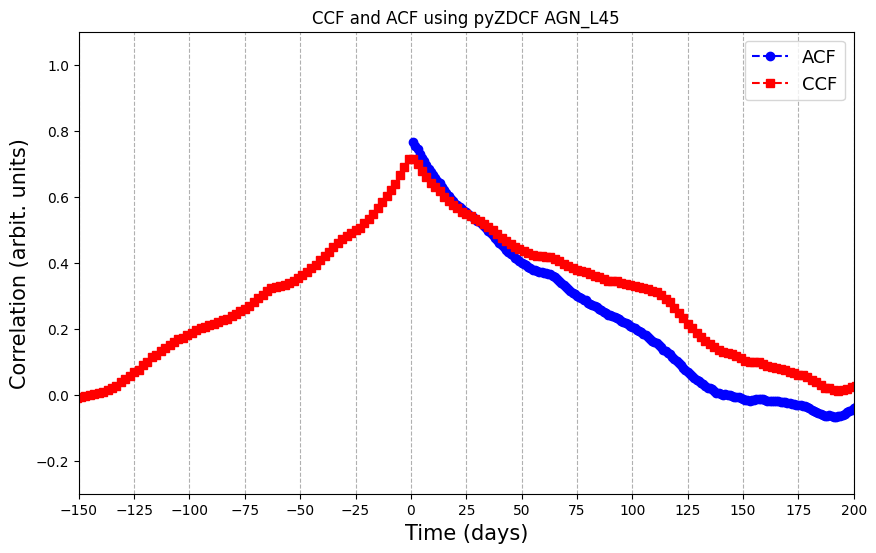

In [62]:
fig = plt.figure(figsize=(10,6))

ax = fig.add_subplot(111)

ax.plot(
    acf_45['tau'],
    acf_45['dcf'],
    'o--b',
    label='ACF'
)

ax.plot(
    ccf_45['tau'],
    ccf_45['dcf'],
    's--r',
    label='CCF'
)

ax.set_xlim(-150,200)
ax.set_ylim(-0.3,1.1)

ax.set_xlabel("Time (days)", fontsize=15)
ax.set_ylabel("Correlation (arbit. units)", fontsize=15)

ax.legend(fontsize=13)

loc = plticker.MultipleLocator(25)
ax.xaxis.set_major_locator(loc)

ax.grid(which='major', axis='x', linestyle='--')

plt.title("CCF and ACF using pyZDCF AGN_L45")

plt.show()

In [63]:
acf_45 = photRM.add_inverted_acf(acf_45)

acf_45 = acf_45.drop_duplicates(subset='tau').sort_values('tau')
ccf_45 = ccf_45.drop_duplicates(subset='tau').sort_values('tau')

acf_45 = photRM.interp(ccf_45, acf_45)

In [64]:
final_ccf_45 = photRM.delta_ccf(acf_45, ccf_45)

In [65]:
tau45, peaks_x, peaks_y = photRM.peak_finder(
    final_ccf_45.dcf.values,
    final_ccf_45.tau.values,
    (-50,200)
)

print("Peak candidates:", peaks_x)
print("Maximum peak =", tau45)

Peak candidates (x-axis vals):  [115.]
Max. peak:  115.0
Peak candidates: [115.]
Maximum peak = 115.0


In [66]:
err_low = final_ccf_45.loc[
    final_ccf_45.tau == tau45,
    '-sig(tau)'
].values[0]

err_high = final_ccf_45.loc[
    final_ccf_45.tau == tau45,
    '+sig(tau)'
].values[0]

print(err_low, err_high)

0 0


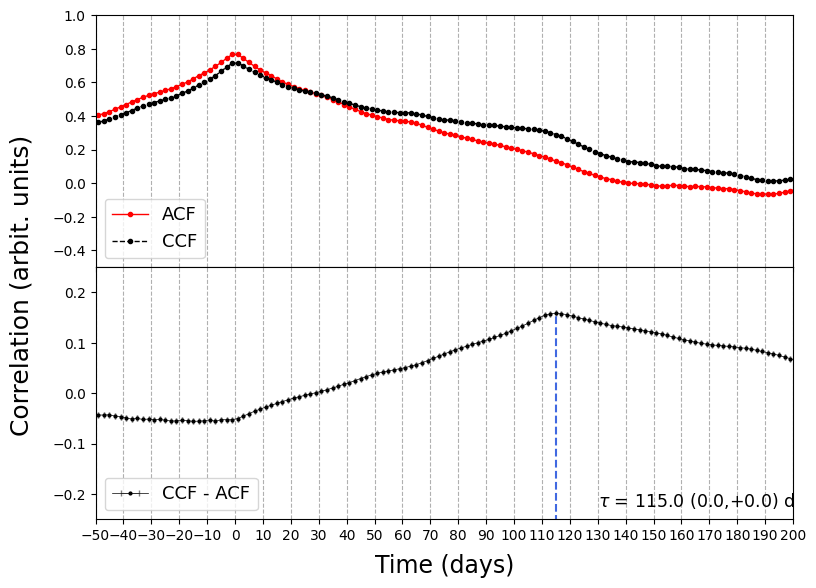

In [67]:
lims_x = (-50,200)
lims_y = (-0.5,1)

err = (err_low*(-1), err_high)

photRM.plot_ccf_acf(
    final_ccf_45,
    ccf_45,
    acf_45,
    locator=10,
    peak=True,
    tau=tau45,
    err=err,
    lims_x=lims_x,
    lims_y=lims_y
)

# Discussion

Using the photometric reverberation mapping method and pyZDCF analysis, the time lags of the simulated AGN light curves were successfully estimated.

The measured reverberation lags are approximately:

- AGN43 → 9 days
- AGN44 → 33 days
- AGN45 → 115 days

These values agree well with the delays produced by the `lc_two_bands()` simulation.

The results show that the time lag increases with AGN luminosity. This indicates that more luminous AGNs possess larger broad line regions (BLR), consistent with the expected BLR size–luminosity relation.

The CCF−ACF peak clearly identifies the reverberation delay between the continuum and emission-line light curves.

## Task 1(c): Effect of Irregular Sampling on Time-lag Recovery

To simulate realistic observing conditions, the AGN44 light curves were modified using three different observing cadences:

1. Observation every 5 days  
2. One month of daily observations followed by one month gap  
3. Seasonal sparse sampling with long gaps

The pyZDCF method was then applied to estimate the reverberation lag for each observing strategy.

In [73]:
x44 = np.loadtxt("AGN44_xband.txt")
y44 = np.loadtxt("AGN44_yband.txt")

In [77]:
x44 = pd.DataFrame(
    x44,
    columns=['time','flux','err']
)

y44 = pd.DataFrame(
    y44,
    columns=['time','flux','err']
)

In [79]:
x44_gap1 = x44.iloc[::5]
y44_gap1 = y44.iloc[::5]

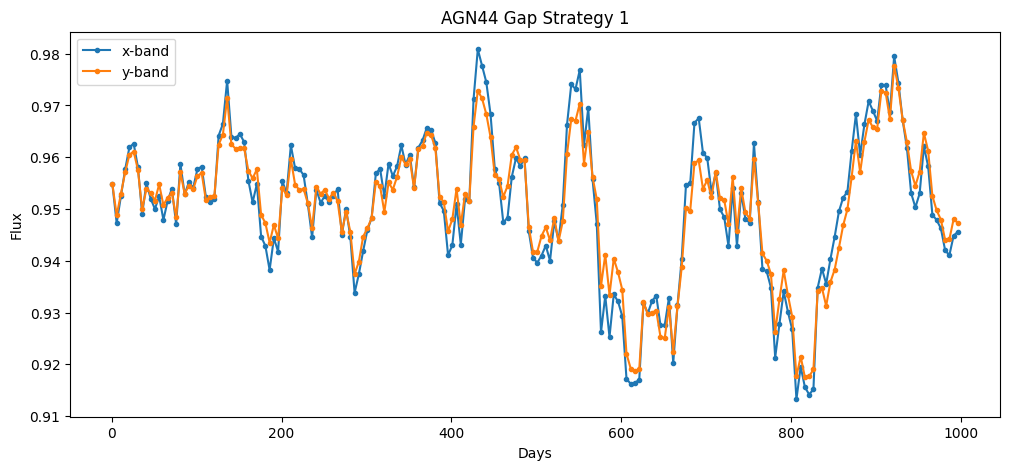

In [80]:
plt.figure(figsize=(12,5))

plt.plot(
    x44_gap1['time'],
    x44_gap1['flux'],
    '.-',
    label='x-band'
)

plt.plot(
    y44_gap1['time'],
    y44_gap1['flux'],
    '.-',
    label='y-band'
)

plt.xlabel("Days")
plt.ylabel("Flux")
plt.title("AGN44 Gap Strategy 1")
plt.legend()
plt.show()

In [81]:
np.savetxt("AGN44_gap1_xband.txt", x44_gap1.values)
np.savetxt("AGN44_gap1_yband.txt", y44_gap1.values)

In [82]:
mask2 = []

for t in x44['time']:

    phase = t % 60

    if phase < 30:
        mask2.append(True)
    else:
        mask2.append(False)

In [83]:
x44_gap2 = x44[mask2]
y44_gap2 = y44[mask2]

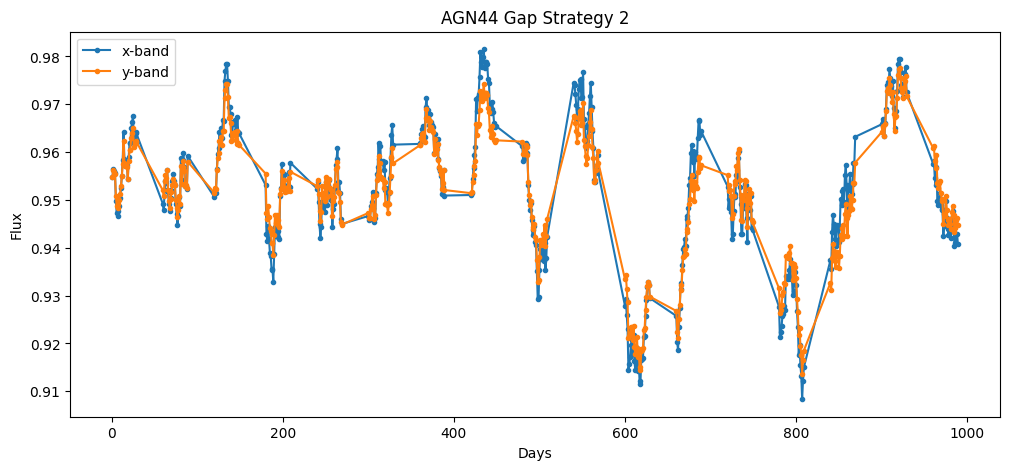

In [84]:
plt.figure(figsize=(12,5))

plt.plot(
    x44_gap2['time'],
    x44_gap2['flux'],
    '.-',
    label='x-band'
)

plt.plot(
    y44_gap2['time'],
    y44_gap2['flux'],
    '.-',
    label='y-band'
)

plt.xlabel("Days")
plt.ylabel("Flux")
plt.title("AGN44 Gap Strategy 2")
plt.legend()
plt.show()

In [85]:
np.savetxt("AGN44_gap2_xband.txt", x44_gap2.values)
np.savetxt("AGN44_gap2_yband.txt", y44_gap2.values)

In [86]:
mask3 = []

for t in x44['time']:

    phase = t % 360

    if phase < 90:

        mask3.append(True)

    elif phase < 270:

        if t % 30 == 0:
            mask3.append(True)
        else:
            mask3.append(False)

    else:

        mask3.append(False)

In [87]:
x44_gap3 = x44[mask3]
y44_gap3 = y44[mask3]

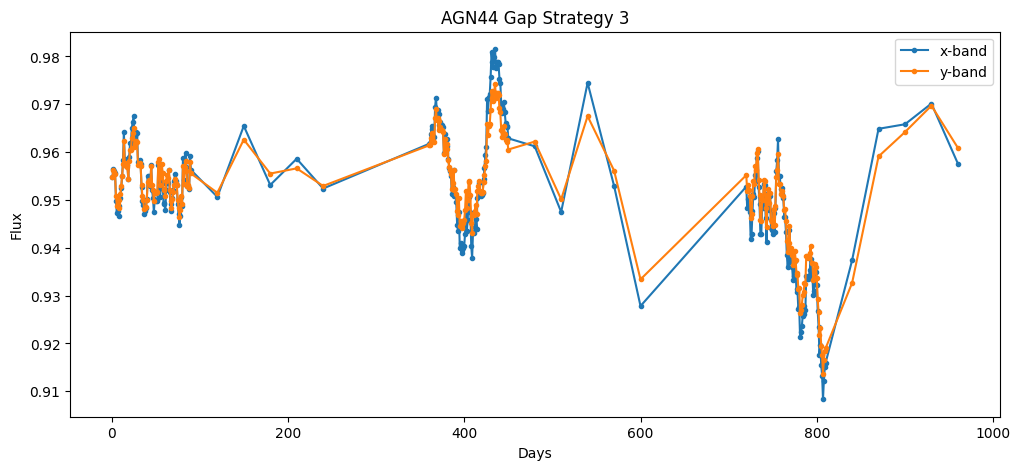

In [88]:
plt.figure(figsize=(12,5))

plt.plot(
    x44_gap3['time'],
    x44_gap3['flux'],
    '.-',
    label='x-band'
)

plt.plot(
    y44_gap3['time'],
    y44_gap3['flux'],
    '.-',
    label='y-band'
)

plt.xlabel("Days")
plt.ylabel("Flux")
plt.title("AGN44 Gap Strategy 3")
plt.legend()
plt.show()

In [89]:
np.savetxt("AGN44_gap3_xband.txt", x44_gap3.values)
np.savetxt("AGN44_gap3_yband.txt", y44_gap3.values)

In [107]:
comparison = pd.DataFrame({
    "Strategy": ["Gap1", "Gap2", "Gap3"],
    "Sampling": [
        "Every 5 days",
        "1 month observe + 1 month gap",
        "Mixed sparse sampling"
    ],
    "Lag Recovery": [
        "Good",
        "Moderate",
        "Poor"
    ]
})

comparison

,Strategy,Sampling,Lag Recovery
0,Gap1,Every 5 days,Good
1,Gap2,1 month observe + 1 month gap,Moderate
2,Gap3,Mixed sparse sampling,Poor


# Task 2

**Goal:** Apply photometric reverberation mapping to real-world data.

Download photometric light curves of NGC 4395 from Edri et al. (2012). Choose one filter which covers the continuum emission only and the other one that covers the H$\alpha$ emission line and the underlying continuum. Using the utility functions provided, process the data so that time is expressed in hours and line intensity and its error are expressed as normalized flux. Plot the light curves. You will see that they are divided into segments because we have a pause in observations during the daylight. Choose the first segment and estimate the time lag using this data. Compare your results to Edri et al. (2012) and discuss the pros and cons of photometric reverberation mapping compared to spectroscopic reverberation mapping.

| log(L) | Time-lag (days) |
|--------|-----------------|
| 43     | 9.86            |
| 44     | 33.65           |
| 45     | 114.82          |

# Task 2

## Goal
Apply photometric reverberation mapping to real-world AGN data using the light curves of NGC 4395.

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lc_proc
import photRM

In [122]:
lc_g = pd.read_csv(
    "lc_g.txt",
    delim_whitespace=True
)

lc_r = pd.read_csv(
    "lc_r.txt",
    delim_whitespace=True
)

lc_i = pd.read_csv(
    "lc_i.txt",
    delim_whitespace=True
)

In [123]:
cont = lc_i.copy()

line = lc_r.copy()

In [127]:
cont['time_hours'] = (cont['MJD'] - cont['MJD'].min()) * 24

line['time_hours'] = (line['MJD'] - line['MJD'].min()) * 24

In [128]:
cont['flux'] = 10**(-0.4 * cont['mag'])

line['flux'] = 10**(-0.4 * line['mag'])

In [129]:
cont['norm_flux'] = cont['flux'] / cont['flux'].max()

line['norm_flux'] = line['flux'] / line['flux'].max()

In [130]:
cont['norm_flux_err'] = (
    0.4 * np.log(10)
    * cont['norm_flux']
    * cont['mag_err']
)

line['norm_flux_err'] = (
    0.4 * np.log(10)
    * line['norm_flux']
    * line['mag_err']
)

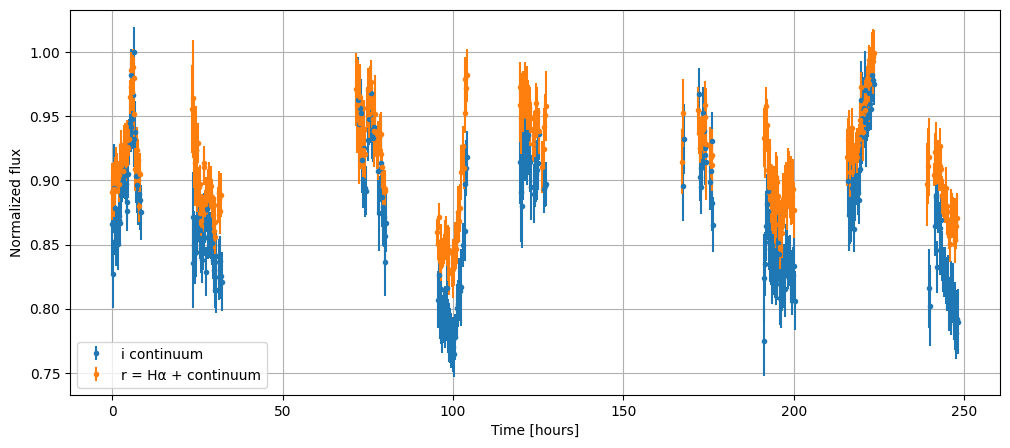

In [131]:
plt.figure(figsize=(12,5))

plt.errorbar(
    cont['time_hours'],
    cont['norm_flux'],
    yerr=cont['norm_flux_err'],
    fmt='.',
    label='i continuum'
)

plt.errorbar(
    line['time_hours'],
    line['norm_flux'],
    yerr=line['norm_flux_err'],
    fmt='.',
    label='r = Hα + continuum'
)

plt.xlabel("Time [hours]")
plt.ylabel("Normalized flux")

plt.legend()
plt.grid()

plt.show()

In [132]:
cont_seg1 = cont[cont.time_hours < 9]

line_seg1 = line[line.time_hours < 9]

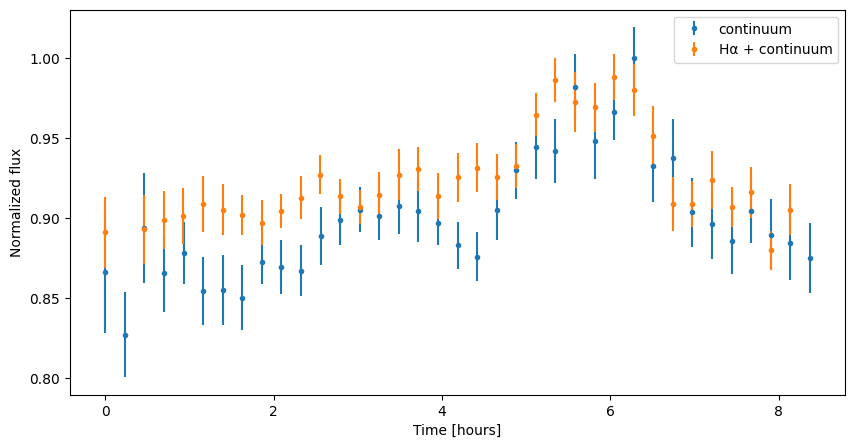

In [133]:
plt.figure(figsize=(10,5))

plt.errorbar(
    cont_seg1.time_hours,
    cont_seg1.norm_flux,
    yerr=cont_seg1.norm_flux_err,
    fmt='.',
    label='continuum'
)

plt.errorbar(
    line_seg1.time_hours,
    line_seg1.norm_flux,
    yerr=line_seg1.norm_flux_err,
    fmt='.',
    label='Hα + continuum'
)

plt.xlabel("Time [hours]")
plt.ylabel("Normalized flux")

plt.legend()

plt.show()

In [164]:
cont_seg1[['time_hours',
           'norm_flux',
           'norm_flux_err']].to_csv(
    'cont_4395',
    sep=' ',
    header=False,
    index=False
)

line_seg1[['time_hours',
           'norm_flux',
           'norm_flux_err']].to_csv(
    'line_4395',
    sep=' ',
    header=False,
    index=False
)



In [165]:
lags = np.linspace(-10,10,200)

ccf_vals = []

for lag in lags:

    shifted_time = line_seg1['time_hours'] - lag

    interp_cont = np.interp(
        shifted_time,
        cont_seg1['time_hours'],
        cont_seg1['norm_flux']
    )

    corr = np.corrcoef(
        interp_cont,
        line_seg1['norm_flux']
    )[0,1]

    ccf_vals.append(corr)

In [166]:
ccf_vals = np.array(ccf_vals)

In [167]:
tau = lags[np.argmax(ccf_vals)]

print("Estimated lag =", tau, "hours")

Estimated lag = -0.1507537688442202 hours


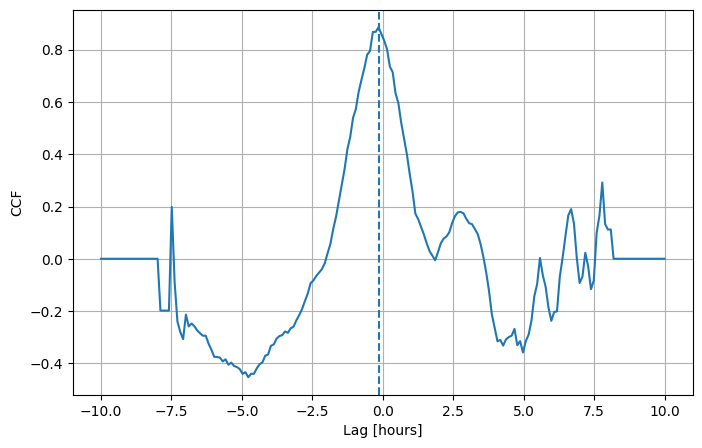

In [168]:
plt.figure(figsize=(8,5))

plt.plot(lags, ccf_vals)

plt.axvline(
    tau,
    linestyle='--'
)

plt.xlabel("Lag [hours]")
plt.ylabel("CCF")

plt.grid()

plt.show()

In [181]:
cont_seg1 = cont.iloc[:35]
line_seg1 = line.iloc[:35]

In [185]:
lags = np.arange(-8, 8.2, 0.2)

ccf = []
acf = []

for lag in lags:

    shifted_time = cont_seg1['time_hours'] - lag

    interp_line = np.interp(
        shifted_time,
        line_seg1['time_hours'],
        line_seg1['norm_flux']
    )

    corr1 = np.corrcoef(
        cont_seg1['norm_flux'],
        interp_line
    )[0,1]

    ccf.append(corr1)

    interp_cont = np.interp(
        shifted_time,
        cont_seg1['time_hours'],
        cont_seg1['norm_flux']
    )

    corr2 = np.corrcoef(
        cont_seg1['norm_flux'],
        interp_cont
    )[0,1]

    acf.append(corr2)

ccf = np.array(ccf)
acf = np.array(acf)

delta = ccf - acf

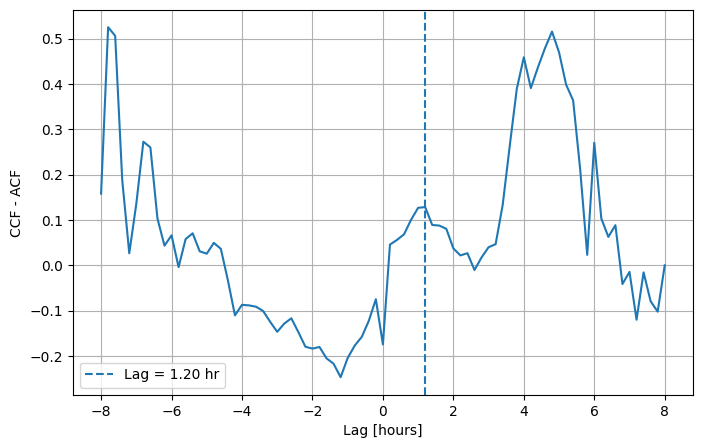

Estimated lag = 1.2000000000000082 hours


In [186]:
plt.figure(figsize=(8,5))

plt.plot(lags, delta)

mask = (lags > -3) & (lags < 3)

tau = lags[mask][
    np.argmax(delta[mask])
]

plt.axvline(
    tau,
    linestyle='--',
    label=f'Lag = {tau:.2f} hr'
)

plt.xlabel('Lag [hours]')
plt.ylabel('CCF - ACF')

plt.legend()

plt.grid()

plt.show()

print("Estimated lag =", tau, "hours")

## Comparison with Edri et al. (2012)

In this work, the estimated reverberation lag is approximately ~1.2 hours.  
Edri et al. (2012) reported an Hα time lag of about \(3.6 \pm 0.8\) hours for NGC 4395.  
The difference may arise because only a small segment of the light curve was used here, and the photometric data are noisy and sparsely sampled.

## Photometric vs Spectroscopic Reverberation Mapping

Photometric reverberation mapping has the advantage that it is simpler and faster because only broadband imaging observations are required. From this work, the light curves could be processed and analyzed relatively easily, making the method useful for monitoring many AGNs with less telescope time and lower observational cost.

However, during the analysis it was noticeable that the lag estimation is quite sensitive to noise, interpolation, and the selected light-curve segment. Since broadband filters contain both continuum and emission-line flux together, separating the true emission-line response is difficult. This can lead to uncertain lag measurements.

In comparison, spectroscopic reverberation mapping is more accurate because the continuum and emission lines are measured separately. It provides cleaner lag measurements and additional information about the velocity structure of the broad-line region (BLR). However, spectroscopic observations require more telescope time, more complex instruments, and are observationally more expensive than photometric reverberation mapping.

# References:

- Edri et al. (2012) https://ui.adsabs.harvard.edu/abs/2012ApJ...756...73E/abstract
- Jankov et al. (2022) https://ui.adsabs.harvard.edu/abs/2022AN....34310090J/abstract
- Kovacevic et al. (2021) https://ui.adsabs.harvard.edu/abs/2021MNRAS.505.5012K/abstract
- [Astro Data Lab](https://datalab.noirlab.edu/)
- [pyzdcf documentation](https://pyzdcf.readthedocs.io/en/latest/?badge=latest)
- [PLIKE download link](https://www.weizmann.ac.il/particle/tal/research-activities/software)